# [[7,1,3]] Steane QSS — entanglement fidelity

The reference ancilla is maximally entangled with the secret, the Steane QSS channel is applied to the secret half, and the recovered qubit is compared with the untouched reference.  `ERASED_SHARES` is validated against the minimal access structure, so this notebook can reproduce both the two-erasure circuit and the special correctable three/four-erasure cases.

The direct Bell projector gives a quick estimate of Eq. (5); the `StateTomography` block follows the measurement method used in the paper.

**Execution controls:** choose `BACKEND_MODE = "ideal"`, `"fake_brisbane"`, or `"fake_torino"`. The fake modes use `AerSimulator.from_backend(...)` for local noisy simulation. `USE_M3=True` applies M3 readout mitigation to the final metric measurements and projects the resulting quasi-distribution to the nearest physical probability distribution (L2-norm). M3 does **not** retroactively correct the mid-circuit syndrome bits used for feed-forward.

**Must set up your authentication for access to actual quantum hardware**

PAPER: https://arxiv.org/abs/2410.11640 or https://www.mdpi.com/1099-4300/27/10/993

In [1]:
# The fake backends provide IBM device snapshots; Aer executes noisy simulations from them.
# %pip install "qiskit>=2.0" "qiskit[visualization]" "qiskit-aer>=0.17" "qiskit-ibm-runtime" "mthree>=3.0" matplotlib

In [2]:
from itertools import product, combinations
import numpy as np

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.result import marginal_counts
from qiskit.quantum_info import Statevector, state_fidelity

np.set_printoptions(precision=6, suppress=True)

In [3]:
# -------------------- USER CONFIG --------------------
ERASED_SHARES = (6, 7)      # or another correctable set from the access-structure helper
SHOTS = 10_000              # 10,000 shots for tomography
OPTIMIZATION_LEVEL = 0      # 0, 1, 2, 3
RUN_TOMOGRAPHY = True

# Execution / mitigation
BACKEND_MODE = "ideal"   # "ideal", "fake_brisbane", or "fake_torino"
USE_M3 = True
M3_CAL_SHOTS = 10_000
M3_CAL_METHOD = "independent"    # fast/suitable for simulator calibration
SEED_TRANSPILE = 12345
SEED_SIMULATOR = 12345
# -----------------------------------------------------


In [4]:
# Paper Fig. 5 / Sec. III B.  Secret enters/reappears on physical qubit 1 (index 0).
N = 7
OUTPUT_QUBIT = 0
SYNDROME_QUBITS = (1, 2, 3, 4, 5, 6)

# Reverse of the stabilizer-reduction sequence in Eq. (7), including the Z on q1
# visible at both ends of Figs. 5 and 11.
ENCODER_GATES = [
    ("z", 0),
    ("h", 4), ("h", 5), ("h", 6),
    ("cx", 0, 1), ("cx", 0, 2),
    ("cx", 6, 0), ("cx", 6, 1), ("cx", 6, 3),
    ("cx", 5, 0), ("cx", 5, 2), ("cx", 5, 3),
    ("cx", 4, 1), ("cx", 4, 2), ("cx", 4, 3),
]
DECODER_GATES = list(reversed(ENCODER_GATES))

ALL_SHARES = frozenset(range(1, 8))
STEANE_MINIMAL_AUTHORIZED = tuple(map(frozenset, [
    (1, 2, 3), (1, 4, 5), (1, 6, 7), (2, 4, 6),
    (2, 5, 7), (3, 4, 7), (3, 5, 6),
]))


def steane_is_authorized(shares):
    S = frozenset(shares)
    return any(A <= S for A in STEANE_MINIMAL_AUTHORIZED)


def steane_erasure_is_correctable(erased_shares):
    """For this pure-state QSS code, discarded E must be unauthorized and E^c authorized."""
    E = frozenset(erased_shares)
    if not E <= ALL_SHARES:
        return False
    survivors = ALL_SHARES - E
    return (not steane_is_authorized(E)) and steane_is_authorized(survivors)


def correctable_steane_erasures(size):
    return [c for c in combinations(sorted(ALL_SHARES), size)
            if steane_erasure_is_correctable(c)]


def validate_steane_erasure(erased_shares):
    E = tuple(sorted(set(erased_shares)))
    if len(E) != len(tuple(erased_shares)):
        raise ValueError("Do not repeat a share index.")
    if not set(E) <= ALL_SHARES:
        raise ValueError(f"Shares must be chosen from {sorted(ALL_SHARES)}")
    if not steane_erasure_is_correctable(E):
        survivors = tuple(sorted(ALL_SHARES - set(E)))
        raise ValueError(
            f"E={E} is not a correctable erasure set for the Steane QSS access structure. "
            f"Survivors are {survivors}. Use correctable_steane_erasures(len(E)) "
            "to list valid choices of the same size."
        )
    return E


def prepare_qubit_secret(qc, qubit, theta, phi):
    qc.rx(theta, qubit)
    qc.rz(phi, qubit)


In [5]:
PAULIS = "IXYZ"
XZ_TO_PAULI = {(0, 0): "I", (1, 0): "X", (0, 1): "Z", (1, 1): "Y"}


def _conj_h(x, z, q):
    x[q], z[q] = z[q], x[q]


def _conj_cx(x, z, c, t):
    # Clifford propagation, phases discarded.
    x[t] ^= x[c]
    z[c] ^= z[t]


def _conj_cz(x, z, a, b):
    z[a] ^= x[b]
    z[b] ^= x[a]


def propagate_pauli_through_decoder(n, error_ops, decoder_gates):
    """Propagate a Pauli supported on physical code qubits through U^†.

    error_ops is an iterable of (qubit_index, 'I'/'X'/'Y'/'Z').
    Only the binary symplectic label is needed; global phases are irrelevant.
    """
    x = [0] * n
    z = [0] * n
    for q, p in error_ops:
        if p in ("X", "Y"):
            x[q] ^= 1
        if p in ("Z", "Y"):
            z[q] ^= 1

    for gate in decoder_gates:
        kind = gate[0]
        if kind == "h":
            _conj_h(x, z, gate[1])
        elif kind == "cx":
            _conj_cx(x, z, gate[1], gate[2])
        elif kind == "cz":
            _conj_cz(x, z, gate[1], gate[2])
        elif kind in ("x", "z"):
            # Conjugation by X/Z changes at most a phase.
            pass
        else:
            raise ValueError(f"Unsupported Clifford gate in propagation list: {gate}")
    return x, z


def derive_erasure_correction_lookup(n, erased_zero_based, decoder_gates,
                                     syndrome_qubits, output_qubit):
    """Return syndrome-int -> logical Pauli correction for a known erasure set.

    Each syndrome clbit i is paired with syndrome_qubits[i], so the integer used
    by QuantumCircuit.if_test is sum(bit_i * 2**i).
    """
    by_syndrome = {}
    erased_zero_based = tuple(erased_zero_based)

    for pattern in product(PAULIS, repeat=len(erased_zero_based)):
        error_ops = list(zip(erased_zero_based, pattern))
        x, z = propagate_pauli_through_decoder(n, error_ops, decoder_gates)
        syndrome_bits = tuple(x[q] for q in syndrome_qubits)
        syndrome_int = sum(bit << i for i, bit in enumerate(syndrome_bits))
        logical = XZ_TO_PAULI[(x[output_qubit], z[output_qubit])]
        by_syndrome.setdefault(syndrome_int, set()).add(logical)

    collisions = {s: ops for s, ops in by_syndrome.items() if len(ops) != 1}
    if collisions:
        raise ValueError(
            "This erasure set is not correctable by the selected code/recovery. "
            f"Ambiguous syndrome(s): {collisions}"
        )
    return {s: next(iter(ops)) for s, ops in by_syndrome.items()}


def syndrome_tuple_to_int(bits):
    return sum(int(bit) << i for i, bit in enumerate(bits))


def append_gate_list(qc, qreg, gates):
    for gate in gates:
        kind = gate[0]
        if kind == "h":
            qc.h(qreg[gate[1]])
        elif kind == "x":
            qc.x(qreg[gate[1]])
        elif kind == "z":
            qc.z(qreg[gate[1]])
        elif kind == "cx":
            qc.cx(qreg[gate[1]], qreg[gate[2]])
        elif kind == "cz":
            qc.cz(qreg[gate[1]], qreg[gate[2]])
        else:
            raise ValueError(gate)


def apply_feedforward_corrections(qc, syndrome_register, output_qubit, lookup):
    """Paper-style mid-circuit measurement + classical feed-forward."""
    for syndrome_int, pauli in sorted(lookup.items()):
        if pauli == "I":
            continue
        with qc.if_test((syndrome_register, syndrome_int)):
            getattr(qc, pauli.lower())(output_qubit)


def make_execution_backend(mode=BACKEND_MODE):
    """Return an Aer execution backend.

    Modes
    -----
    ideal          : noiseless AerSimulator
    fake_brisbane  : Aer noise model / coupling / basis derived from FakeBrisbane
    fake_torino    : Aer noise model / coupling / basis derived from FakeTorino

    For the fake modes, AerSimulator.from_backend(...) copies the fake device
    snapshot into a local noisy simulator.  Circuits are transpiled against this
    simulator, so the final physical-qubit mapping can be passed directly to M3.
    """
    mode = mode.lower()
    if mode == "ideal":
        return AerSimulator(), "ideal AerSimulator"

    try:
        from qiskit_ibm_runtime.fake_provider import FakeBrisbane, FakeTorino
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError(
            "Fake backends require qiskit-ibm-runtime. Uncomment the %pip install cell."
        ) from exc

    if mode == "fake_brisbane":
        snapshot = FakeBrisbane()
    elif mode == "fake_torino":
        snapshot = FakeTorino()
    else:
        raise ValueError(
            "BACKEND_MODE must be 'ideal', 'fake_brisbane', or 'fake_torino'."
        )
    return AerSimulator.from_backend(snapshot), snapshot.name


EXECUTION_BACKEND, BACKEND_LABEL = make_execution_backend()
print("Execution backend:", BACKEND_LABEL)
print("M3 enabled:", USE_M3)


def run_counts(circuit, shots=20000, optimization_level=0, backend=None):
    backend = EXECUTION_BACKEND if backend is None else backend
    compiled = transpile(
        circuit,
        backend,
        optimization_level=optimization_level,
        seed_transpiler=SEED_TRANSPILE,
    )
    result = backend.run(
        compiled,
        shots=shots,
        seed_simulator=SEED_SIMULATOR,
    ).result()
    return compiled, result.get_counts()


def _m3_module():
    try:
        import mthree
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError(
            "USE_M3=True requires mthree. Uncomment the %pip install cell."
        ) from exc
    return mthree


def selected_raw_marginal(counts, circuit, clbits):
    indices = [circuit.find_bit(c).index for c in clbits]
    return marginal_counts(counts, indices=indices)


def m3_mitigated_marginal(compiled, counts, original_circuit, clbits, backend=None):
    """M3-correct only the requested *final metric* bits.

    This intentionally does not attempt to change the single-shot syndrome values
    that drove mid-circuit feed-forward. M3 can correct ensemble measurement
    statistics, but not a classical decision that already happened during a shot.
    """
    mthree = _m3_module()
    backend = EXECUTION_BACKEND if backend is None else backend
    indices = [original_circuit.find_bit(c).index for c in clbits]
    full_mapping = mthree.utils.final_measurement_mapping(compiled)
    marginal_raw, marginal_mapping = mthree.utils.marginal_distribution(
        counts, indices, full_mapping
    )
    mit = mthree.M3Mitigation(backend)
    mit.cals_from_system(
        marginal_mapping,
        shots=M3_CAL_SHOTS,
        method=M3_CAL_METHOD,
        async_cal=False,
    )
    quasi = mit.apply_correction(marginal_raw, marginal_mapping)
    # Maps M3 quasi-probabilities to the closest probability
    # distribution in L2 norm before reporting probabilities/fidelities.
    probs = quasi.nearest_probability_distribution()
    return marginal_raw, quasi, probs, marginal_mapping


def probability_zero_from_distribution(dist):
    total = float(sum(dist.values()))
    if total == 0:
        return float("nan")
    return float(dist.get("0", 0.0) / total)


def probability_all_zero_from_distribution(dist, nbits):
    total = float(sum(dist.values()))
    if total == 0:
        return float("nan")
    return float(dist.get("0" * nbits, 0.0) / total)




def build_direct_bell_projector(base_circuit, ref_register, code_register):
    """Append the inverse Bell-state preparation and measure the two fidelity bits.

    If the reference qubit and recovered logical qubit are exactly in
        |Phi+> = (|00> + |11>)/sqrt(2),
    then CX(ref -> recovered) followed by H(ref) maps them to |00>.
    Therefore P(fid == '00') is the direct entanglement-fidelity projector
    estimate.

    The qubit indices are resolved in ``base_circuit`` and then re-bound to the
    copied circuit.  This avoids relying on Qubit object identity across
    ``QuantumCircuit.copy()``.
    """
    qc = base_circuit.copy()

    ref_idx = base_circuit.find_bit(ref_register[0]).index
    out_idx = base_circuit.find_bit(code_register[OUTPUT_QUBIT]).index

    ref_q = qc.qubits[ref_idx]
    out_q = qc.qubits[out_idx]

    # Inverse of Bell preparation: H(ref), CX(ref,out) was the preparation,
    # so apply CX(ref,out), H(ref) for the projector.
    qc.cx(ref_q, out_q)
    qc.h(ref_q)

    fid = ClassicalRegister(2, "fid")
    qc.add_register(fid)
    qc.measure(ref_q, fid[0])
    qc.measure(out_q, fid[1])
    return qc, fid

# -------- M3-aware Pauli state tomography --------
# This explicitly runs the 3^n X/Y/Z measurement settings so the same M3
# correction can be applied to every tomography histogram before reconstruction.

_TOMO_PAULI_MATS = {
    "I": np.array([[1, 0], [0, 1]], dtype=complex),
    "X": np.array([[0, 1], [1, 0]], dtype=complex),
    "Y": np.array([[0, -1j], [1j, 0]], dtype=complex),
    "Z": np.array([[1, 0], [0, -1]], dtype=complex),
}


def _probabilities_from_counts(counts):
    total = float(sum(counts.values()))
    return {key.replace(" ", ""): value / total for key, value in counts.items()}


def _expectation_from_distribution(dist, pauli_tuple):
    n = len(pauli_tuple)
    value = 0.0
    for key, prob in dist.items():
        bitstring = "".join(ch for ch in str(key) if ch in "01")
        if len(bitstring) != n:
            raise ValueError(f"Expected {n}-bit marginal, got key {key!r}")
        # Qiskit displays classical bit n-1 on the left and bit 0 on the right.
        bits = [int(ch) for ch in bitstring[::-1]]
        parity = sum(bits[i] for i, p in enumerate(pauli_tuple) if p != "I") % 2
        value += (-1.0 if parity else 1.0) * float(prob)
    return value


def _pauli_operator(pauli_tuple):
    # Qiskit little-endian convention: highest-index local qubit is leftmost
    # in the Kronecker product representation.
    out = np.array([[1.0 + 0j]])
    for p in reversed(pauli_tuple):
        out = np.kron(out, _TOMO_PAULI_MATS[p])
    return out


def _linear_inversion_density(probabilities_by_setting, n):
    dim = 2 ** n
    rho = np.zeros((dim, dim), dtype=complex)
    for pauli_tuple in product("IXYZ", repeat=n):
        if all(p == "I" for p in pauli_tuple):
            expval = 1.0
        else:
            setting = tuple(p if p != "I" else "Z" for p in pauli_tuple)
            expval = _expectation_from_distribution(
                probabilities_by_setting[setting], pauli_tuple
            )
        rho += expval * _pauli_operator(pauli_tuple)
    rho /= dim
    return (rho + rho.conj().T) / 2


def _pure_state_fidelity_from_rho(rho, target_statevector):
    psi = np.asarray(target_statevector.data, dtype=complex)
    value = float(np.real(np.vdot(psi, rho @ psi)))
    return float(np.clip(value, 0.0, 1.0))


def run_m3_state_tomography(base_circuit, target_qubits, target_statevector,
                            shots=10000, optimization_level=0, backend=None):
    """Return raw and (optionally) M3-mitigated linear-inversion fidelities.

    target_qubits is an ordered sequence of qubit objects in base_circuit. The
    reconstructed density matrix uses exactly that local ordering.
    """
    backend = EXECUTION_BACKEND if backend is None else backend
    target_indices = [base_circuit.find_bit(q).index for q in target_qubits]
    n = len(target_indices)
    settings = list(product("XYZ", repeat=n))
    circuits = []

    for axes in settings:
        qc = base_circuit.copy()
        tomo = ClassicalRegister(n, "tomo")
        qc.add_register(tomo)
        for i, (qidx, axis) in enumerate(zip(target_indices, axes)):
            q = qc.qubits[qidx]
            if axis == "X":
                qc.h(q)
            elif axis == "Y":
                qc.sdg(q)
                qc.h(q)
            qc.measure(q, tomo[i])
        circuits.append(qc)

    compiled = transpile(
        circuits,
        backend,
        optimization_level=optimization_level,
        seed_transpiler=SEED_TRANSPILE,
    )
    result = backend.run(
        compiled,
        shots=shots,
        seed_simulator=SEED_SIMULATOR,
    ).result()
    raw_counts = result.get_counts()
    if isinstance(raw_counts, dict):
        raw_counts = [raw_counts]

    # The tomography register is appended after any syndrome registers.
    tomo_indices = list(range(base_circuit.num_clbits, base_circuit.num_clbits + n))

    if USE_M3:
        mthree = _m3_module()
        mappings = mthree.utils.final_measurement_mapping(compiled)
        marg_counts = []
        marg_mappings = []
        for counts, mapping in zip(raw_counts, mappings):
            mc, mm = mthree.utils.marginal_distribution(counts, tomo_indices, mapping)
            marg_counts.append(mc)
            marg_mappings.append(mm)

        mit = mthree.M3Mitigation(backend)
        mit.cals_from_system(
            marg_mappings,
            shots=M3_CAL_SHOTS,
            method=M3_CAL_METHOD,
            async_cal=False,
        )
        quasis = mit.apply_correction(marg_counts, marg_mappings)
        mitigated_probs = [q.nearest_probability_distribution() for q in quasis]
    else:
        marg_counts = [marginal_counts(c, indices=tomo_indices) for c in raw_counts]
        mitigated_probs = None

    raw_probs = [_probabilities_from_counts(c) for c in marg_counts]
    raw_by_setting = dict(zip(settings, raw_probs))
    rho_raw = _linear_inversion_density(raw_by_setting, n)
    fid_raw = _pure_state_fidelity_from_rho(rho_raw, target_statevector)

    out = {
        "raw_fidelity": fid_raw,
        "raw_density_matrix": rho_raw,
        "compiled_circuits": compiled,
    }
    if mitigated_probs is not None:
        mit_by_setting = dict(zip(settings, mitigated_probs))
        rho_m3 = _linear_inversion_density(mit_by_setting, n)
        out["m3_fidelity"] = _pure_state_fidelity_from_rho(rho_m3, target_statevector)
        out["m3_density_matrix"] = rho_m3
    return out


Execution backend: ideal AerSimulator
M3 enabled: True


In [6]:
print("Correctable size-3 erasures:", correctable_steane_erasures(3))
print("Correctable size-4 erasures:", correctable_steane_erasures(4))
ERASED_SHARES = validate_steane_erasure(ERASED_SHARES)
print("Selected E:", ERASED_SHARES)
print("Survivors:", tuple(sorted(ALL_SHARES - set(ERASED_SHARES))))


Correctable size-3 erasures: [(1, 2, 4), (1, 2, 5), (1, 2, 6), (1, 2, 7), (1, 3, 4), (1, 3, 5), (1, 3, 6), (1, 3, 7), (1, 4, 6), (1, 4, 7), (1, 5, 6), (1, 5, 7), (2, 3, 4), (2, 3, 5), (2, 3, 6), (2, 3, 7), (2, 4, 5), (2, 4, 7), (2, 5, 6), (2, 6, 7), (3, 4, 5), (3, 4, 6), (3, 5, 7), (3, 6, 7), (4, 5, 6), (4, 5, 7), (4, 6, 7), (5, 6, 7)]
Correctable size-4 erasures: [(1, 2, 4, 7), (1, 2, 5, 6), (1, 3, 4, 6), (1, 3, 5, 7), (2, 3, 4, 5), (2, 3, 6, 7), (4, 5, 6, 7)]
Selected E: (6, 7)
Survivors: (1, 2, 3, 4, 5)


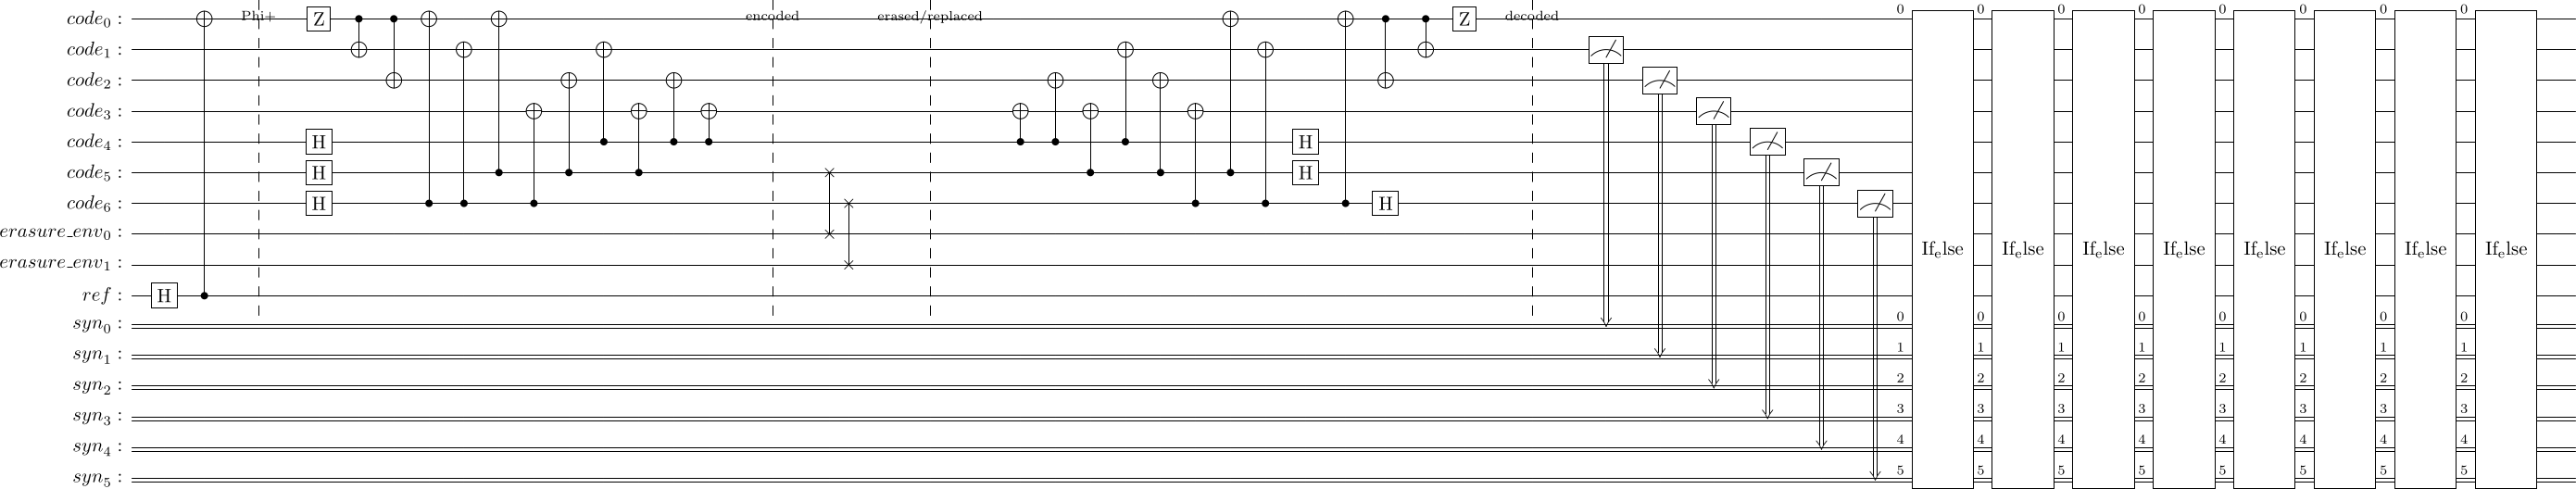

In [7]:
def build_entanglement_channel_circuit(erased_shares=ERASED_SHARES):
    erased_shares = validate_steane_erasure(erased_shares)
    erased0 = tuple(s - 1 for s in erased_shares)
    lookup = derive_erasure_correction_lookup(
        N, erased0, DECODER_GATES, SYNDROME_QUBITS, OUTPUT_QUBIT
    )

    code_q = QuantumRegister(7, "code")
    fresh = QuantumRegister(len(erased0), "erasure_env")
    ref = QuantumRegister(1, "ref")
    syn = ClassicalRegister(6, "syn")
    qc = QuantumCircuit(code_q, fresh, ref, syn)

    qc.h(ref[0])
    qc.cx(ref[0], code_q[OUTPUT_QUBIT])
    qc.barrier(label="Phi+")
    
    append_gate_list(qc, code_q, ENCODER_GATES)
    qc.barrier(label="encoded")
    
    for anc, q in zip(fresh, erased0):
        qc.swap(anc, code_q[q])
    qc.barrier(label="erased/replaced")
    
    append_gate_list(qc, code_q, DECODER_GATES)
    qc.barrier(label="decoded")
    
    for i, q in enumerate(SYNDROME_QUBITS):
        qc.measure(code_q[q], syn[i])
    apply_feedforward_corrections(qc, syn, code_q[OUTPUT_QUBIT], lookup)
    return qc, ref, code_q


channel_qc, ref, code_q = build_entanglement_channel_circuit()
display(channel_qc.draw(output='latex', cregbundle=False))

In [8]:
projector_qc, fid = build_direct_bell_projector(channel_qc, ref, code_q)
compiled, counts = run_counts(projector_qc, shots=SHOTS, optimization_level=OPTIMIZATION_LEVEL)
raw_fid_counts = selected_raw_marginal(counts, projector_qc, list(fid))
Fe_raw = probability_all_zero_from_distribution(raw_fid_counts, 2)
print("Backend:", BACKEND_LABEL)
print("Direct raw entanglement fidelity estimate:", Fe_raw)
print("Raw projector counts:", raw_fid_counts)

if USE_M3:
    _, quasi, m3_probs, mapping = m3_mitigated_marginal(
        compiled, counts, projector_qc, list(fid)
    )
    Fe_m3 = probability_all_zero_from_distribution(m3_probs, 2)
    print("M3 physical-qubit mapping:", mapping)
    print("Direct M3 entanglement fidelity estimate:", Fe_m3)
    print("M3 nearest probability distribution:", m3_probs)


Backend: ideal AerSimulator
Direct raw entanglement fidelity estimate: 1.0
Raw projector counts: {'00': 10000}
M3 physical-qubit mapping: {0: 9, 1: 0}
Direct M3 entanglement fidelity estimate: 1.0
M3 nearest probability distribution: {'00': np.float32(1.0)}


In [9]:
if RUN_TOMOGRAPHY:
    bell = Statevector([1 / np.sqrt(2), 0, 0, 1 / np.sqrt(2)])
    tomo = run_m3_state_tomography(
        channel_qc,
        [ref[0], code_q[OUTPUT_QUBIT]],
        bell,
        shots=SHOTS,
        optimization_level=OPTIMIZATION_LEVEL,
    )
    print("Tomographic raw entanglement fidelity:", tomo["raw_fidelity"])
    if USE_M3:
        print("Tomographic M3 entanglement fidelity:", tomo["m3_fidelity"])


Tomographic raw entanglement fidelity: 0.9999999999999998
Tomographic M3 entanglement fidelity: 0.9999999925494192
